In [ ]:
import os
import timeit

import numpy as np
import pandas as pd
import plotnine as p9
from IPython import get_ipython

import pyvinecopulib as pv

ipython = get_ipython()

# Display plots inline in Jupyter Notebook
ipython.run_line_magic("matplotlib", "inline")

# Minimal reporting for exception handlers
ipython.run_line_magic("xmode", "minimal")

# Automatically reload modules when they have changed
ipython.run_line_magic("load_ext", "autoreload")
ipython.run_line_magic("autoreload", "2")

# Display all output from a cell (not just the last line)
ipython.run_line_magic(
  "config", "InteractiveShell.ast_node_interactivity='all'"
)

# Set display options for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("max_colwidth", None)
pd.set_option("display.precision", 3)

# Numpy settings
np.printoptions(
  precision=4,
  suppress=True,
  formatter={"float": "{:0.4f}".format},
  linewidth=80,
)

Exception reporting mode: Minimal


In [ ]:
from sklearn.model_selection import train_test_split
from vinesforest.vines_forest import VinesForest

# Read data
n_vines = 100
seed = 42
num_threads = min(32, os.cpu_count() + 4)  # See default for concurrent.futures
data = pd.read_csv("data/daxreturns.csv")

data_train, data_test = train_test_split(
  data,
  test_size=0.2,
  random_state=seed,
)

# Fit with Dissmann and forest
start = timeit.default_timer()
fitted_dissmann = pv.Vinecop.from_data(
  data.values,
  controls=pv.FitControlsVinecop(family_set=[pv.tll], num_threads=num_threads),
)
loglik_dissmann = fitted_dissmann.loglik()
time_dissmann = timeit.default_timer() - start

start = timeit.default_timer()
fitted_forest = VinesForest(
  n_vines=n_vines,
  controls=pv.FitControlsVinecop(family_set=[pv.tll], num_threads=num_threads),
)
fitted_forest.fit(data.values)
loglik_forest = fitted_forest.loglik(data.values)
time_forest = timeit.default_timer() - start

# Dissman vs max forest
print(loglik_dissmann)
print(max([x[1] for x in loglik_forest]))

# Time
print(time_dissmann)
print(time_forest)

# Proportion of the forest that is better than the dissman
print(np.mean([x[1] > loglik_dissmann for x in loglik_forest]))

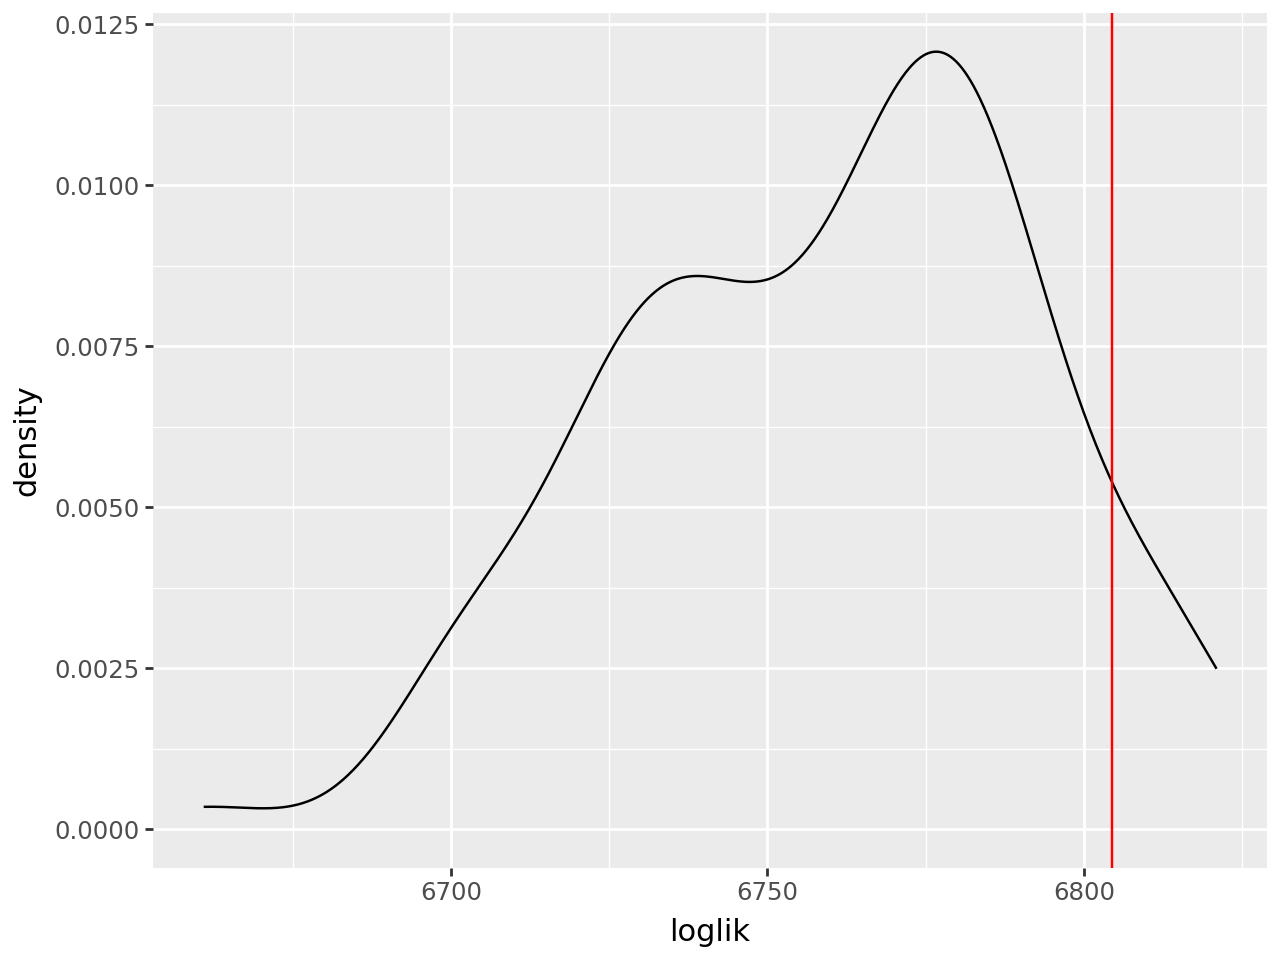

In [ ]:
df = pd.DataFrame(loglik_forest, columns=["seed", "loglik"])

p = (
  p9.ggplot(df, p9.aes(x="loglik"))
  + p9.geom_density()
  + p9.geom_vline(xintercept=loglik_dissmann, color="red")
)
p.show()

In [ ]:
# Get the best seed
best_seed = max(loglik_forest, key=lambda x: x[1])[0]

# Fit the best vine using the VinesForest method
best_vine = VinesForest.fit_random_vine(
  data.values,
  seed=best_seed,
  controls=pv.FitControlsVinecop(family_set=[pv.tll], num_threads=1),
)

# Verify that the best vine has the loglik previously found
assert best_vine.loglik(data.values) == max([x[1] for x in loglik_forest])

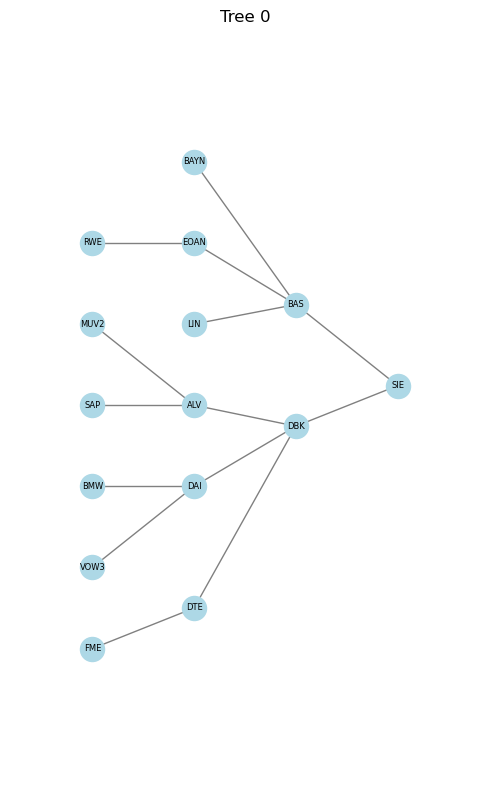

In [66]:
fitted_dissmann.plot(
  tree=[0],
  vars_names=list(data.columns.str.replace(".DE", "")),
  add_edge_labels=False,
)

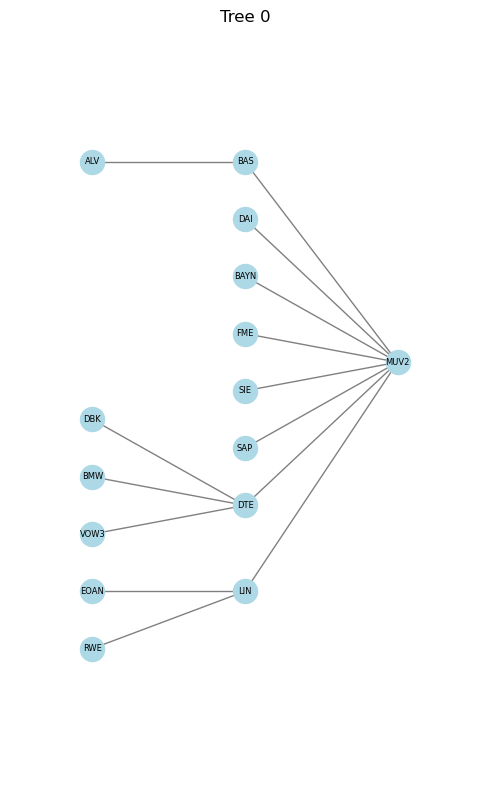

In [65]:
best_vine.plot(
  tree=[0],
  vars_names=list(data.columns.str.replace(".DE", "")),
  add_edge_labels=False,
)